# Physics 234 Final
## April 16, 2025  830-1130 AM

Do the following problems. Use the Jupyter notebook, inserting your code and any textual answers/explanations in cells between the questions. (Feel free to add additional cells!) Marks will be given based on how clearly you demonstrate your understanding.

There are no restrictions on downloading from the internet, eclass, or the use of books, notes, or any other widely available computing resources. However, you are not allowed to communicate with others or collaborate in any way and uploading to the internet or sending or receiving direct communications is not appropriate. AI engines like ChatGPT are not appropriate.  

When you are finished, upload the jupyter notebook to Canvas. Canvas times out at 11:30 so make sure that you upload things before then. Also be careful to save the notebook periodically and that you upload the file that contains all your work.

Note: some people have trouble viewing figures inside the jupyter notebook. There is a pdf file of the exam that contains the figures that can also be downloaded and viewed.

## 1. Integration and Interpolation

Consider the function $$f(t;t_0,t_1,t_2)=\begin{cases}e^{-\frac{t_0-t}{t_1}} & t<t_0\\ e^{-\frac{t-t_0}{t_2}} & t>t_0 \end{cases}$$

Write the python function `f(t,t0,t1,t2)`.

Set $t_0=4~\rm{ns}$, $t_1=2~\rm{ns}$, $t_2=0.5~\rm{ns}$ and plot the function between -15 ns and 9 ns.

Text(0, 0.5, 'f(t)')

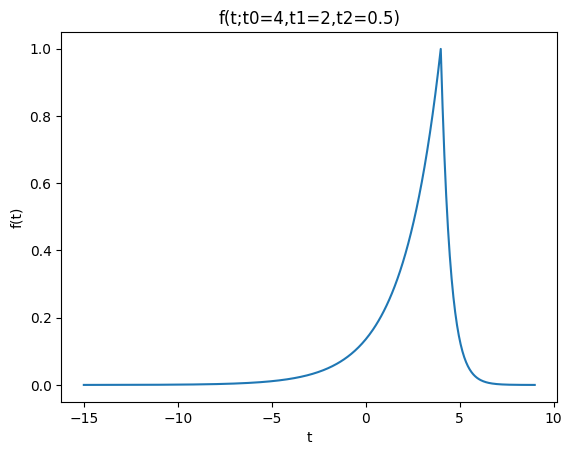

In [1]:
import numpy as np
import matplotlib.pyplot as plt
def f(t,t0,t1,t2):
    return np.where(t<t0,np.exp(-(t0-t)/t1),np.exp(-(t-t0)/t2))

tlist=np.linspace(-15,9,500)
plt.plot(tlist,f(tlist,4,2,0.5))
plt.title("f(t;t0=4,t1=2,t2=0.5)")
plt.xlabel("t")
plt.ylabel("f(t)")

What is $\int_{-15}^{9}f(t;4,2,0.5)dt$? Print out 3 decimal places.

In [2]:
from scipy.integrate import quad
integral,_=quad(f,-15,9,args=(4,2,0.5))
print(f' The integral is {integral:5.3f}')

 The integral is 2.500



We modify the function by convolving it using a function $$P(t_m;t,\sigma)=\frac{1}{\sqrt{2\pi}\sigma} e^\frac{-(t_m-t)^2}{2\sigma^2}$$
The convolution is $$f_2(t_m;t_0,t_1,t_2,\sigma)=\int_{-15}^9 f(t;t_0,t_1,t_2)P(t_m;t,\sigma) dt$$

Plot $f_2(t_m)$ between -15 and 9 ns. Set $t_0=4~\rm{ns}$, $t_1=2~\rm{ns}$, $t_2=0.5~\rm{ns}$ and $\sigma=1.0~\rm{ns}$


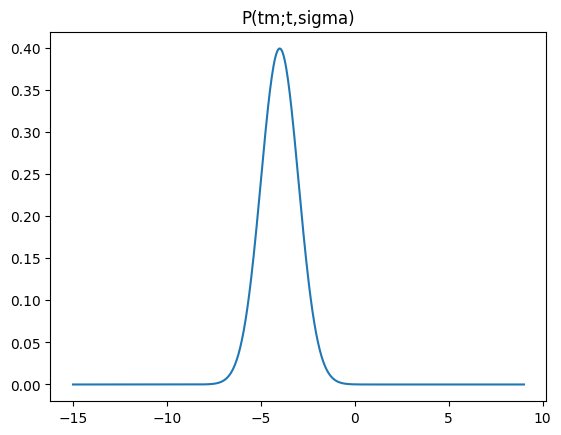

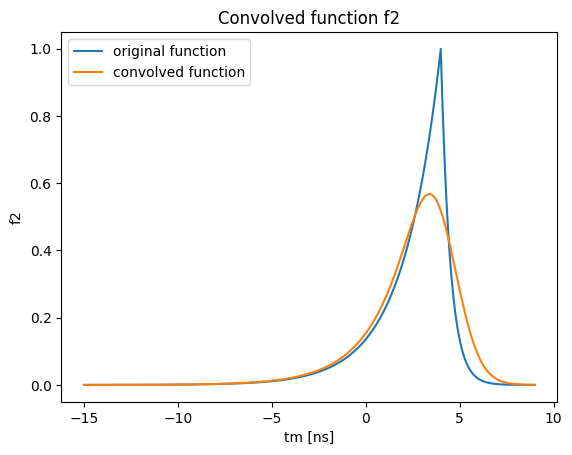

In [3]:
def P(tm,t,sigma):
    return 1/np.sqrt(2*np.pi)/sigma*np.exp(-(tm-t)**2/2/sigma**2)

plt.plot(tlist,P(-4,tlist,1))
plt.title("P(tm;t,sigma)")
plt.show()

def f2(tm,t0,t1,t2,sigma):
    return quad(lambda t:f(t,t0,t1,t2)*P(tm,t,sigma),-15,9)[0]

#  could also do f3=np.vectorize(f2)

f2l=np.array([f2(tm,4,2,0.5,1)for tm in tlist])
plt.plot(tlist,f(tlist,4,2,0.5), label='original function')
plt.plot(tlist,f2l,label='convolved function')
plt.title("Convolved function f2");
plt.xlabel("tm [ns]")
plt.ylabel("f2")
plt.legend()

Now interpolate $f_2$ with a polynomial.  What degree is necessary to get an RMS deviation of the interpolation from the function to be less than 1e-10?

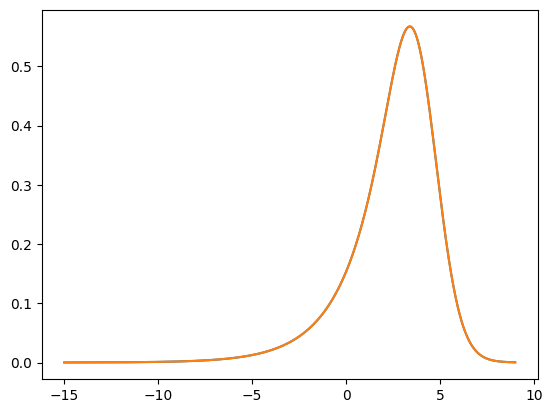

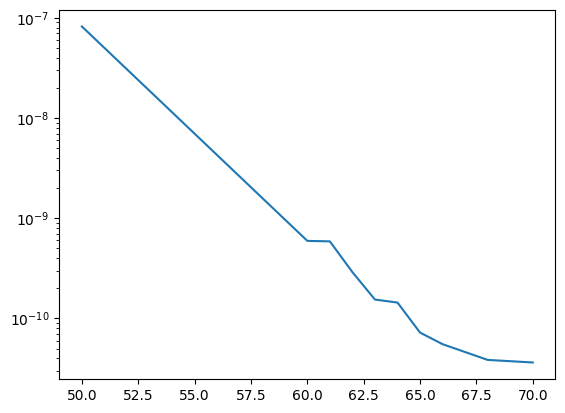

[8.207328765980455e-08, 5.937913137078461e-10, 5.869420650544034e-10, 2.892001450643868e-10, 1.540325561818077e-10, 1.4375365037048977e-10, 7.207319745420815e-11, 5.520979431203772e-11, 3.847085442762836e-11, 3.62673993657486e-11]


In [12]:
from numpy.polynomial.chebyshev import chebval, chebinterpolate
f3=np.vectorize(f2)
cc=chebinterpolate(lambda x:f3(x*12-3,4,2,0.5,1),100)
plt.plot(tlist,f2l)
plt.plot(tlist,chebval((tlist+3)/12,cc))
plt.show()

tlist=np.linspace(-15,9,1000)
def RMS(N):
    return np.sqrt(np.sum((chebval((tlist+3)/12,cc[:N])-f3(tlist,4,2,0.5,1))**2)/1000)

ir=[50,60,61,62,63,64,65,66,68,70]
rmss=[RMS(i) for i in ir]
plt.plot(ir,rmss)
plt.yscale('log')
plt.show()
print(rmss)
    

From the plot, one reads that degree 65 gives one an rms less than 1e-10.  

## 2. Solid Angle and Monte Carlo
The solid from assignment 3 was calculated with an integration.  In this question we redo the calculation with a Monte Carlo, by generating a flash of photons isotropically from a point at the origin and calculating the number(fraction) that strike our box. 

Generate N=100000 photons isotropically. The output should be an array with N columns of unit vectors. Make a 50 bin histogram for each of the x, y, and z components of the unit vectors to demonstrate that they all follow the same flat distribution.


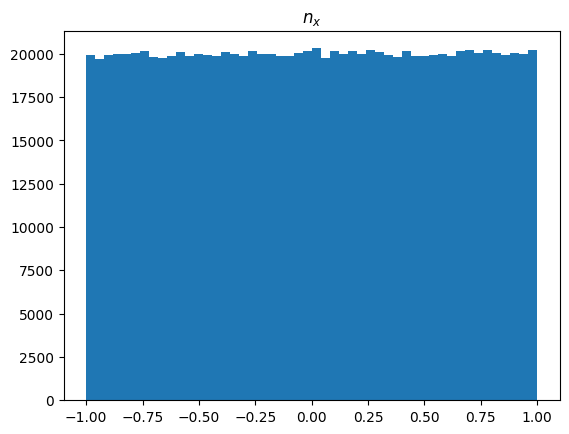

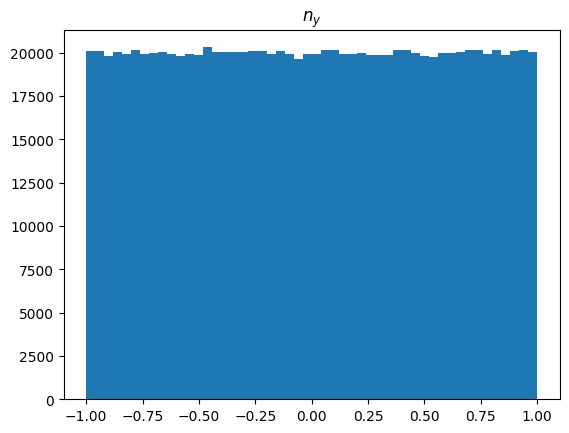

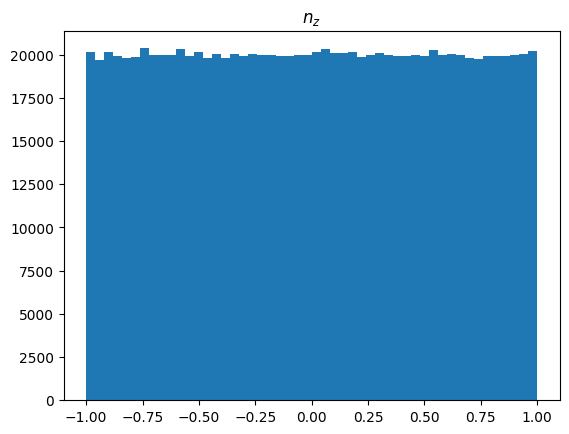

In [4]:
rng=np.random.default_rng()
N=1000000
ct=rng.uniform(-1,1,N)
st=np.sqrt(1-ct**2)
phi=rng.uniform(0,2*np.pi,N)
n=np.array([st*np.cos(phi),st*np.sin(phi),ct])
plt.hist(n[0,:],50)
plt.title('$n_x$')
plt.show()
plt.hist(n[1,:],50)
plt.title('$n_y$')
plt.show()
plt.hist(n[2,:],50)
plt.title('$n_z$')
plt.show()

Each photon has a trajectory $\vec{x}=\vec{x}_0+d\hat{n}$.  In our case the photons all start at the origin so $\vec{x}_0=(0,0,0).$ 
$d$ is the distance the photon has travelled at some instant.

The rectangular box from assignment 3 is shown as a 3d view in the image below:
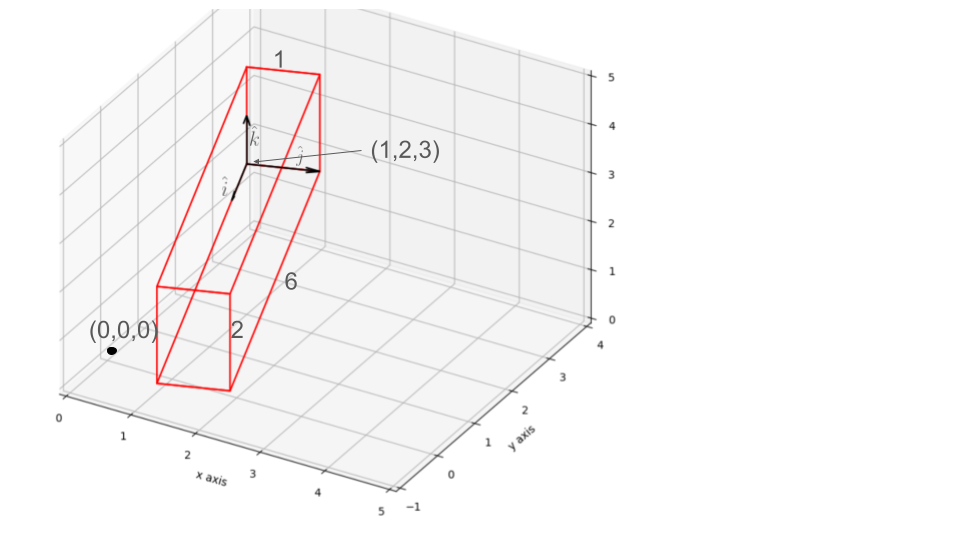

A rectangle in space can be specified by three orthogonal axes- $\hat{i},\hat{j},\hat{k},$ along with $x_1,x_2,y_1,y_2,z_0$.  A point $\vec{x}$ is in the plane of the rectangle if $\vec{x}\cdot\hat{k}=z_0$ and is inside the rectangle if $x_1\le \vec{x}\cdot\hat{i}\le x_2$ and $y_1\le \vec{x}\cdot\hat{j}\le y_2.$

Write a function `testRectangle(n,i,j,k,x1,x2,y1,y2,z0)` that
 1. for each photon direction,$\hat{n}$ in the Monte Carlo array `n`,
 1. solves $(\vec{x}_0+d\hat{n})\cdot \hat{k}=z0$ for $d$ to find the intersection with the plane
 2. checks that $d>0$ (negative d corresponds to photons travelling away from the plane)
 3. checks the intersection point is inside the rectangle.

Return an array of length N where each entry is $d$ if the intersection is good (ie. satisfies conditions 3 and 4) , and `np.inf` if bad.

Test the function with a rectangle from assignment 3. Use unit vectors $\hat{i}=(1,-3,0)/\sqrt{10},\hat{j}=(3,1,0)/\sqrt{10},\hat{k}=(0,0,1))$ and $x_1=1, x_2=7, y_1=2, y_2=3 ,z_0=3.$ For the points with good intersection, plot $\vec{x}\cdot \hat{j}$ vs $\vec{x}\cdot \hat{i}$. Then plot $\phi$ versus $\cos\theta$ for those points.


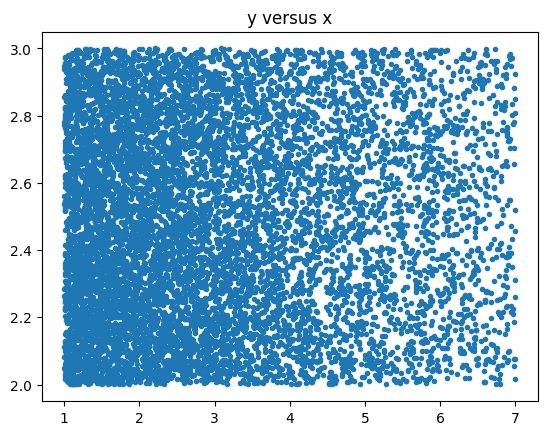

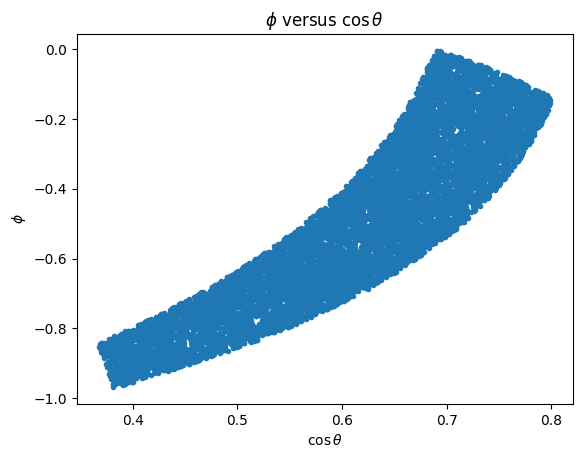

In [5]:
i=np.array([1,-3,0])/np.sqrt(10)
j=np.array([3,1,0])/np.sqrt(10)
k=np.array([0,0,1])

def testRectangle(n,i,j,k,x1,x2,y1,y2,z0):
    dlist=z0/np.dot(k.transpose(),n)
    points=dlist*n
    xlocal=np.dot(i,points)
    y=np.dot(j,points)
    good=(dlist>0)*(x1<=xlocal)*(xlocal<=x2)*(y1<=y)*(y<=y2)
    dlist[np.nonzero(~good)]=np.inf
    return dlist

d1=testRectangle(n,i,j,k,1,7,2,3,3)
elements=np.nonzero(d1<100)
pos=n[:,elements].reshape((3,-1))*d1[elements]
plt.plot(np.dot(i,pos),np.dot(j,pos),'.')
plt.title(r'y versus x')
plt.show()
plt.plot(pos[2,:]/np.linalg.norm(pos,axis=0),np.arctan2(pos[1,:],pos[0,:]),'.')
plt.title(r'$\phi$ versus $\cos\theta$')
plt.xlabel(r'$\cos\theta$')
plt.ylabel('$\phi$')
plt.show()


Now run over the other five rectangles that correspond to the other faces of the rectangular box with length 6 along the $\hat{i}$ axis, width 1 along the $\hat{j}$ axis, and height 2 along the $\hat{k}$ axis, and a corner(1,2,3).  Remember you will need to shift i,j,k around so that the normal to the rectangle is always along the k axis.
Find the minimum d and plot the points.  Calculate the solid angle fraction and histogram the distances.


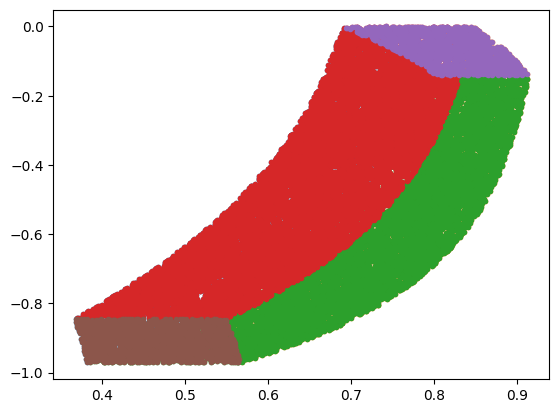

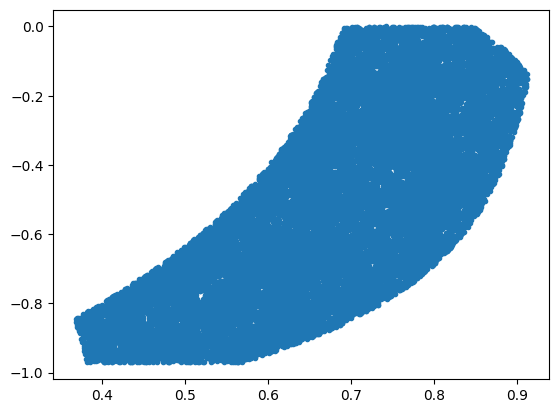

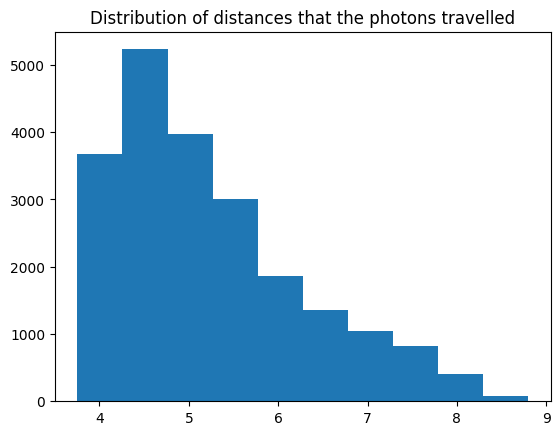

The solid angle fraction is 2.146 %


In [6]:
d=[testRectangle(n,i,j,k,1,7,2,3,3),
   testRectangle(n,i,j,k,1,7,2,3,5),
   testRectangle(n,k,i,j,3,5,1,7,2),
   testRectangle(n,k,i,j,3,5,1,7,3),
   testRectangle(n,j,k,i,2,3,3,5,1),
   testRectangle(n,j,k,i,2,3,3,5,7)]

for dr in d:
    elements=np.nonzero(dr<100)
    pos=n[:,elements].reshape((3,-1))*dr[elements]
    plt.plot(pos[2,:]/np.linalg.norm(pos,axis=0),np.arctan2(pos[1,:],pos[0,:]),'.')

plt.show()

dd=np.min(d,axis=0)
elements=np.nonzero(dd<100)
pos=n[:,elements].reshape((3,-1))*dd[elements]
plt.plot(pos[2,:]/np.linalg.norm(pos,axis=0),np.arctan2(pos[1,:],pos[0,:]),'.')
plt.show()

plt.hist(dd[elements])
plt.title('Distribution of distances that the photons travelled')
plt.show()

print(f'The solid angle fraction is {elements[0].shape[0]/N*100} %')

## 3. Rocket

A rocket carries a 10 kg payload and 190 kg of fuel.  The fuel exits the rocket with a velocity of 2.5 km/s, with respect to the rocket. The rocket burns 10kg/s of fuel.    

This rocket will travel a significant distance, and so we need to do the problem in the reference frame of the earth, and include the spherical shape of the earth. (We will, however, ignore the fact that the earth is rotating and we will also ignore air resistance.  Both can be added to our calculation later.)

Take the radius of the earth as $R_E=6378~\rm{km}$, the initial position of the rocket at latitude 53.5 degrees North, 104 degrees W (basically the position of Edmonton).  

The normal earth coordinate system has the earth's axis of rotation along the z-axis ($\hat{k}$) and the x-axis ($\hat{i}$) along the vector from the center of the earth to the point on the equator at longitude 0. In this system, the initial position is at polar angle $\theta= 90^o-53.5^o=36.5^o$ and azimuthal angle $\phi=-104^o$. In the earth coordinate system this position is $\vec{x}_o=R_E(\sin\theta\cos\phi,\sin\theta\sin\phi, \cos\theta)$. 

Locally, for positioning the rocket we use a flat rectangular coordinate system and specify orthogonal axes "up","north" and "east".  We can express these axes in the earth coordinate system:
 1. "up" is the direction of $\vec{x}_0$:$\hat{u}=\frac{\vec{x}_o}{|\vec{x}_o|}.$
 2. east,$\hat{e}$, is found by $\hat{e}=\frac{\hat{k}\times\hat{u}}{|\hat{k}\times\hat{u}|}$
 3. north, $\hat{n}$ by $\hat{n}=\hat{u}\times \hat{e}$.

The sketch below shows the earth coordinates (on the left) the you should use to calculate the trajectory. It also shows the local coordinates at the launch point, labelled as up, east and north unit vectors. The right image is a zoom onto the (essentially flat) surface of the earth at the launch point on the right, showing the orientation of the rocket with respect to the up, north and east vectors.

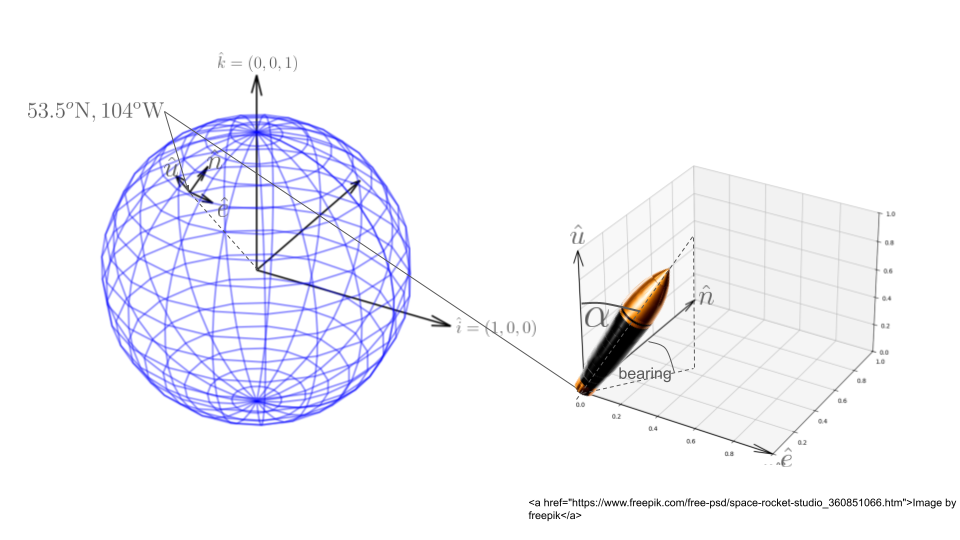

As shown in the figure on the right, we point the rocket by specifying two angles- the angle $\alpha$ between $\hat{u}$(the vertical) and the rocket and the "bearing", that is the angle of the rocket in the north-east plane with respect to North (So North is 0 degrees, East is 90, South 180, West 270).

Write a function `start(latitude, longitude, alpha,bearing)` that returns a 7 dimensional numpy array corresponding to (initial mass, initial position, initial velocity) with the vectors expressed in the earth coordinate system. Start the rocket with the magnitude of the initial velocity 0.001 m/s, and an initial mass of 200 kg. Input the four angles in degrees.

Print out the initial conditions for $\alpha=15^o$ and a bearing of $90^o$.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.constants import g
dmdt0=-10
m0=200
RE=6378e3 # m 

def start(latitude,longitude,alpha,bearing):
    theta=(90-latitude)/180*np.pi
    phi=longitude/180*np.pi
    up=np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    x0=RE*up
    e=np.cross(np.array([0,0,1]),up)
    e=e/np.linalg.norm(e)
    n=np.cross(up,e)
    a=alpha*np.pi/180
    b=bearing*np.pi/180
#    print('b',np.linalg.norm(n),e,n)
    v=(up*np.cos(a)+np.sin(a)*(np.cos(b)*n+np.sin(b)*e))*0.001
#    print(np.dot(v,up),np.dot(v,e),np.dot(v,n))
    return np.concatenate((np.array([m0]),x0,v))

s=start(53.5,-104,15,90)
print(s,np.linalg.norm(s[1:4]),np.linalg.norm(s[4:]))


[ 2.00000000e+02 -9.17798385e+05 -3.68108826e+06  5.12699906e+06
  1.12133653e-04 -6.20101956e-04  7.76466102e-04] 6378000.0 0.001


A rocket is a little different than many other mechanics problems in that the mass is changing. We define $m$ as the mass of the rocket plus the remaining, unburnt, fuel.  We can then derive that $$m\vec{a}=\vec{F}+\vec{v}_e \frac{dm}{dt},$$ where $F$ refers to the sum of the external forces, $\vec{a}$ to the acceleration of the rocket+unburnt fuel, and $\vec{v}_e$ to the velocity of the exhaust *with respect to the rocket*.

Our rocket is designed so it always "points" in the same direction as its velocity, and the exhaust is always pointed opposite to that velocity: $\vec{v}_e=-v_e \frac{\vec{v}}{|\vec{v}|},$ with the convention that $v_e$ without a vector sign is the magnitude of the vector. (This equation is why we start the rocket with a very small, non-zero velocity) Then our equation of motion becomes
$$m\vec{a}=\vec{F}-v_e \frac{\vec{v}}{|\vec{v}|} \frac{dm}{dt}$$ 


 Solve the ordinary differential equation in the case $\vec{F}=0$ (no gravity!) using the initial conditions from above. Stop the integration when the fuel has all been burnt. Plot the height of the rocket above the earth's surface as a function of time, and the straight line distance between the rocket and the launch point. 


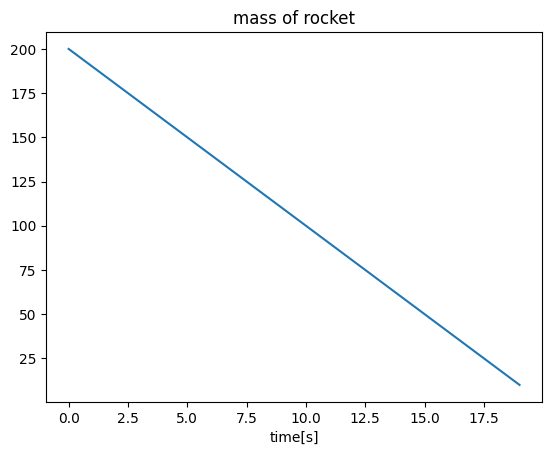

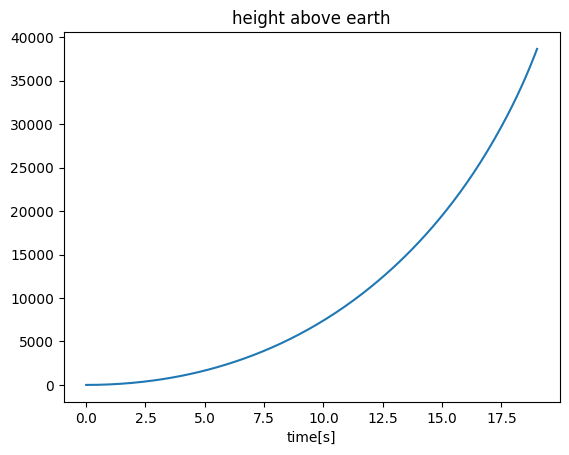

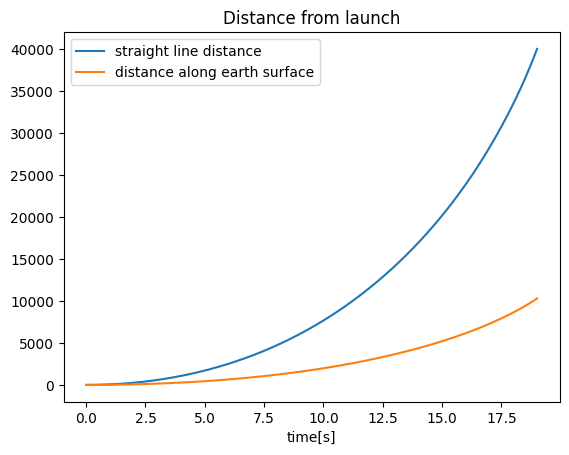

In [66]:

def dmxvdt(t,xv,ve):
    m=xv[0]
    f=np.array([0,0,0]) #external force
    if np.abs(200-10*t-m)>1e-8:
        print("bad")
    x=xv[1:4]
    v=xv[4:]
#    print(f,v,f/m+ve/m*dmdt)
    if t>-190/dmdt0:
        return np.concatenate((np.array([0]),v,f/m))
    return np.concatenate((np.array([dmdt0]),v,f/m-ve/m*dmdt0*v/np.linalg.norm(v)))



s=solve_ivp(dmxvdt,[0,19],start(53.5,-104,15,90) ,args=(2500,),dense_output=True)
tlist= np.linspace(0,19,200)
plt.plot(tlist,s.sol(tlist)[0])
plt.title('mass of rocket')
plt.xlabel('time[s]')
plt.show()
plt.plot(tlist,np.linalg.norm(s.sol(tlist)[1:4],axis=0)-RE)
plt.title('height above earth')
plt.xlabel('time[s]')
plt.show()
plt.plot(tlist,np.linalg.norm(s.sol(tlist)[1:4,:].transpose()-s.y[1:4,0],axis=1),label='straight line distance')
u0=s.y[1:4,0]/np.linalg.norm(s.y[1:4,0])
plt.plot(tlist,[RE*np.arccos(np.dot(u0,s.sol(t)[1:4]/np.linalg.norm(s.sol(t)[1:4])))for t in tlist],label='distance along earth surface')
plt.title("Distance from launch")
plt.xlabel('time[s]')
plt.legend()
plt.show()


Now add surface-of-the-earth gravity, always pointing towards the center of the earth but keep the magnitude $mg$.  Break the trajectory into two parts- the part while the rocket is firing and the part when the rocket is in free fall. Make the same plots as above. On the second plot also overlay the arc length $R_E\beta$ where $\beta$ is the angle the rocket has travelled as measured from the center of the earth. 

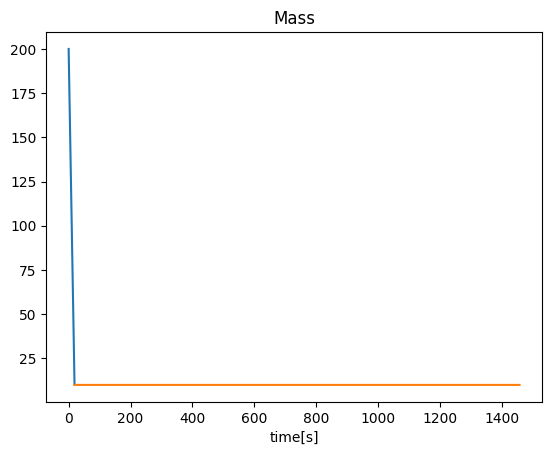

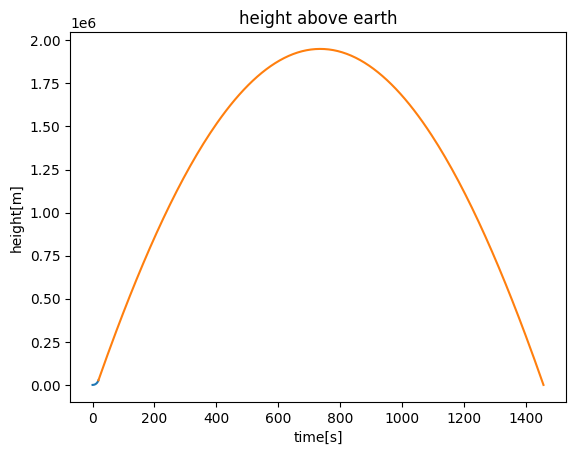

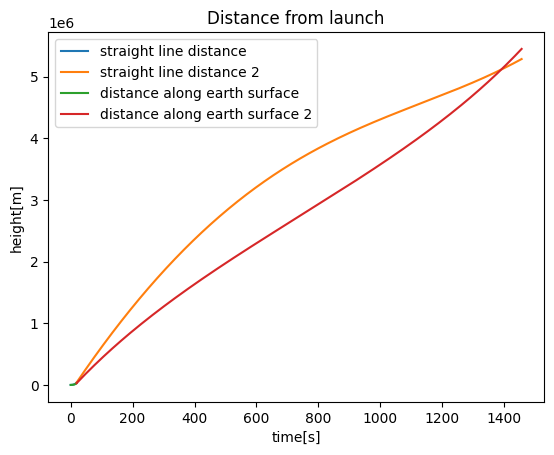

In [8]:
def dmxvdt(t,xv,ve):
    m=xv[0]
    x=xv[1:4]
    v=xv[4:]
#    print(f,v,f/m+ve/m*dmdt)
    f=-m*g*x/np.linalg.norm(x)
    if t>-190/dmdt0:
        return np.concatenate((np.array([0]),v,f/m))
    return np.concatenate((np.array([dmdt0]),v,f/m-ve/m*dmdt0*v/np.linalg.norm(v)))

def stop(t,xv,ve0):
    r= (np.linalg.norm(xv[1:4])-RE)
#    print(r)
    return r

stop.terminal=True;
stop.direction=-1
s=solve_ivp(dmxvdt,[0,19],start(53.5,-104,15,90) ,args=(2500,),dense_output=True)
s2=solve_ivp(dmxvdt,[19,4500],s.y[:,-1],args=(2500,),dense_output=True,events=stop)

tlist= np.linspace(0,19,200)
t2list=np.linspace(19,s2.t_events[0][0],200)
plt.plot(tlist,s.sol(tlist)[0])
plt.plot(t2list,s2.sol(t2list)[0])
plt.title('Mass')
plt.xlabel('time[s]')
plt.show()
plt.plot(tlist,np.linalg.norm(s.sol(tlist)[1:4],axis=0)-RE)
plt.plot(t2list,np.linalg.norm(s2.sol(t2list)[1:4],axis=0)-RE)
plt.title('height above earth')
plt.ylabel('height[m]')
plt.xlabel('time[s]')
plt.show()
plt.plot(tlist,np.linalg.norm(s.sol(tlist)[1:4,:].transpose()-s.y[1:4,0],axis=1),label='straight line distance')
plt.plot(t2list,np.linalg.norm(s2.sol(t2list)[1:4,:].transpose()-s.y[1:4,0],axis=1),label='straight line distance 2')
u0=s.y[1:4,0]/np.linalg.norm(s.y[1:4,0])
plt.plot(tlist,[RE*np.arccos(np.dot(u0,s.sol(t)[1:4]/np.linalg.norm(s.sol(t)[1:4])))for t in tlist],label='distance along earth surface')
plt.plot(t2list,[RE*np.arccos(np.dot(u0,s2.sol(t)[1:4]/np.linalg.norm(s2.sol(t)[1:4])))for t in t2list],label='distance along earth surface 2')
plt.title("Distance from launch")
plt.ylabel('height[m]')
plt.xlabel('time[s]')
plt.legend()
plt.show()

Now change to $1/r^2$ gravity.  The easiest way to do this is to simply scale gravitational force above by $\left(\frac{R_E}{|\vec{x}|}\right)^2$.

Recalculate the trajectory and add the free fall part of the trajectory to the plots above.


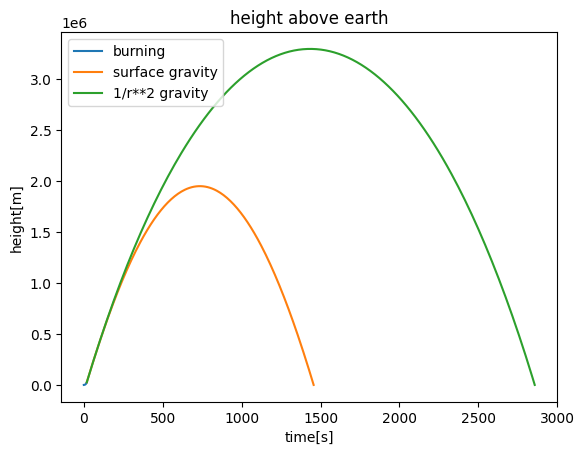

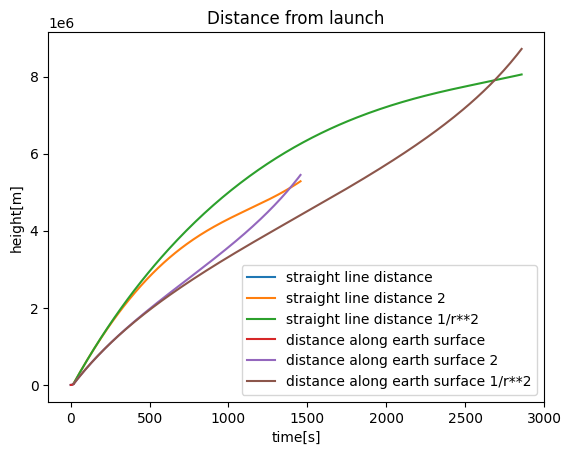

In [10]:
def dmxvdt2(t,xv,ve):
    m=xv[0]
    x=xv[1:4]
    v=xv[4:]
#    print(f,v,f/m+ve/m*dmdt)
    f=-m*g*x*RE**2/np.linalg.norm(x)**3
    if t>-190/dmdt0:
        return np.concatenate((np.array([0]),v,f/m))
    return np.concatenate((np.array([dmdt0]),v,f/m-ve/m*dmdt0*v/np.linalg.norm(v)))

s3a=solve_ivp(dmxvdt2,[0,19],start(53.5,-104,15,90) ,args=(2500,),dense_output=True)
s3=solve_ivp(dmxvdt2,[19,29500],s3a.y[:,-1],args=(2500,),dense_output=True,events=stop)

t3list=np.linspace(19,s3.t[-1],200)

plt.plot(tlist,np.linalg.norm(s.sol(tlist)[1:4],axis=0)-RE,label='burning')
plt.plot(t2list,np.linalg.norm(s2.sol(t2list)[1:4],axis=0)-RE,label='surface gravity')
plt.plot(t3list,np.linalg.norm(s3.sol(t3list)[1:4],axis=0)-RE,label='1/r**2 gravity')
plt.title('height above earth')
plt.ylabel('height[m]')
plt.xlabel('time[s]')
plt.legend()
plt.show()
plt.plot(tlist,np.linalg.norm(s.sol(tlist)[1:4,:].transpose()-s.y[1:4,0],axis=1),label='straight line distance')
plt.plot(t2list,np.linalg.norm(s2.sol(t2list)[1:4,:].transpose()-s.y[1:4,0],axis=1),label='straight line distance 2')
plt.plot(t3list,np.linalg.norm(s3.sol(t3list)[1:4,:].transpose()-s.y[1:4,0],axis=1),label='straight line distance 1/r**2')
u0=s.y[1:4,0]/np.linalg.norm(s.y[1:4,0])
plt.plot(tlist,[RE*np.arccos(np.dot(u0,s.sol(t)[1:4]/np.linalg.norm(s.sol(t)[1:4])))for t in tlist],label='distance along earth surface')
plt.plot(t2list,[RE*np.arccos(np.dot(u0,s2.sol(t)[1:4]/np.linalg.norm(s2.sol(t)[1:4])))for t in t2list],label='distance along earth surface 2')
plt.plot(t3list,[RE*np.arccos(np.dot(u0,s3.sol(t)[1:4]/np.linalg.norm(s3.sol(t)[1:4])))for t in t3list],label='distance along earth surface 1/r**2')
plt.title("Distance from launch")
plt.legend()
plt.ylabel('height[m]')
plt.xlabel('time[s]')
plt.show()
